In [ ]:


import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn

from torchvision import transforms, models

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


base_path = "/content/drive/MyDrive/TFG"

valid_csv = base_path + "/df_valid_clean.csv"

valid_images_path = "/content/valid_clean_images"

model_path = base_path + "/modelo_final_holdout/modelo_final_resnet50_lr001_th04.pth"

output_dir = base_path + "/gradcam_results"
os.makedirs(output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
# CARGAR DATASET

df_valid = pd.read_csv(valid_csv)

urgent_cols = [
    "Pneumothorax",
    "Edema",
    "Pleural Effusion",
    "Enlarged Cardiomediastinum"
]

df_valid["urgent"] = (
    df_valid[urgent_cols] == 1
).any(axis=1).astype(int)

print(df_valid["urgent"].value_counts())

urgent
0    1883
1    1208
Name: count, dtype: int64


In [ ]:
# DESCOMPRIMIR IMÁGENES

if not os.path.exists(valid_images_path):
    !unzip -oq "/content/drive/MyDrive/TFG/valid_clean_images.zip" -d "/content/"
    print("Valid descomprimido")
else:
    print("Valid ya estaba descomprimido")

Valid descomprimido


In [ ]:
# TRANSFORMS

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# CARGAR MODELO FINAL

model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

model.fc = nn.Linear(
    in_features=2048,
    out_features=1
)

model.load_state_dict(
    torch.load(model_path, map_location=device)
)

model = model.to(device)
model.eval()

print("Modelo cargado")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


Modelo cargado


In [ ]:

# CAPA OBJETIVO GRAD-CAM


target_layer = model.layer4[-1]

In [ ]:

#  FUNCIÓN GRAD-CAM


gradients = None
activations = None

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

def forward_hook(module, input, output):
    global activations
    activations = output

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

In [ ]:

# GENERAR GRAD-CAM


def generate_gradcam(img_path):

    image_pil = Image.open(img_path).convert("RGB")

    original = np.array(image_pil.resize((224, 224)))

    input_tensor = transform(image_pil).unsqueeze(0).to(device)

    output = model(input_tensor)

    pred_prob = torch.sigmoid(output).item()

    model.zero_grad()

    output.backward()

    pooled_gradients = torch.mean(
        gradients,
        dim=[0, 2, 3]
    )

    activation = activations[0]

    for i in range(activation.shape[0]):
        activation[i, :, :] *= pooled_gradients[i]

    heatmap = torch.mean(activation, dim=0).cpu().detach().numpy()

    heatmap = np.maximum(heatmap, 0)

    heatmap /= heatmap.max()

    heatmap = cv2.resize(heatmap, (224, 224))

    heatmap_uint8 = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    overlay = cv2.addWeighted(
        original,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    return original, heatmap_color, overlay, pred_prob

In [ ]:

# SELECCIONAR UN EJEMPLO POR CLASE/PATOLOGÍA


selected_rows = []

# 1) Caso No Finding
no_finding_case = df_valid[df_valid["No Finding"] == 1].sample(1, random_state=42)
selected_rows.append(no_finding_case)

# 2) Un caso por cada patología urgente
pathology_examples = [
    "Pneumothorax",
    "Edema",
    "Pleural Effusion",
    "Enlarged Cardiomediastinum"
]

for pathology in pathology_examples:
    case = df_valid[df_valid[pathology] == 1].sample(1, random_state=42)
    selected_rows.append(case)

examples_df = pd.concat(selected_rows).reset_index(drop=True)

# Añadir columna descriptiva para saber qué representa cada imagen
examples_df["case_type"] = [
    "No Finding",
    "Pneumothorax",
    "Edema",
    "Pleural Effusion",
    "Enlarged Cardiomediastinum"
]

examples_df[["case_type", "Path", "urgent"] + urgent_cols]

,case_type,Path,urgent,Pneumothorax,Edema,Pleural Effusion,Enlarged Cardiomediastinum
0,No Finding,CheXpert-v1.0/train/patient09387/study4/view1_...,0,NaN,NaN,0.0,0.0
1,Pneumothorax,CheXpert-v1.0/train/patient09423/study1/view1_...,1,1.0,NaN,1.0,NaN
2,Edema,CheXpert-v1.0/train/patient21197/study1/view1_...,1,NaN,1.0,1.0,NaN
3,Pleural Effusion,CheXpert-v1.0/train/patient01217/study6/view1_...,1,1.0,NaN,1.0,NaN
4,Enlarged Cardiomediastinum,CheXpert-v1.0/train/patient21156/study4/view1_...,1,0.0,NaN,1.0,1.0


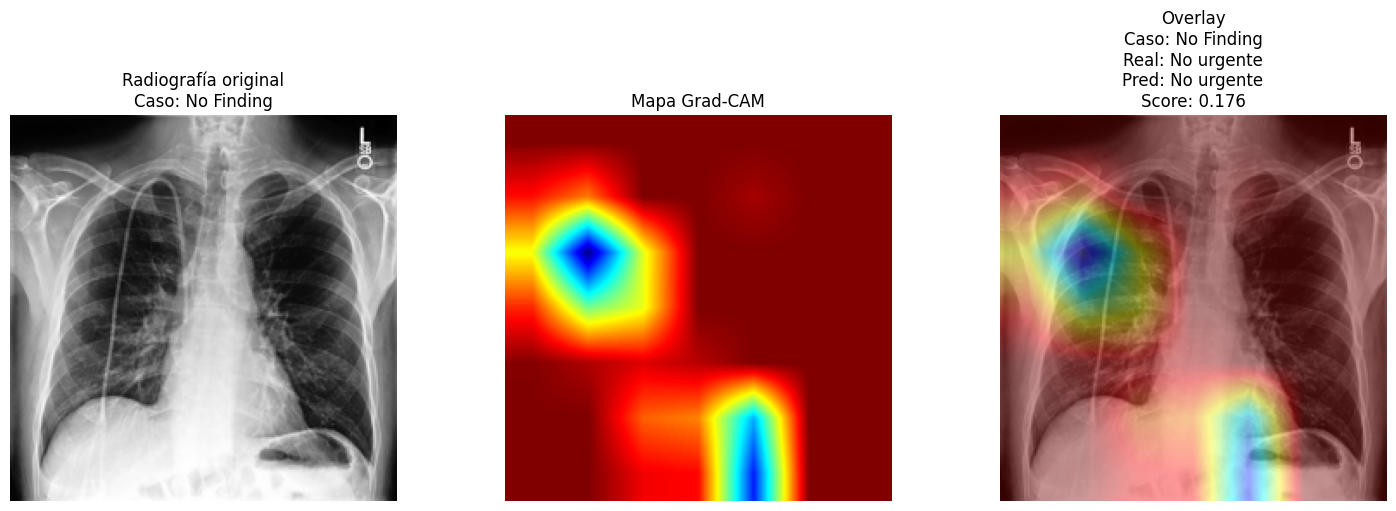

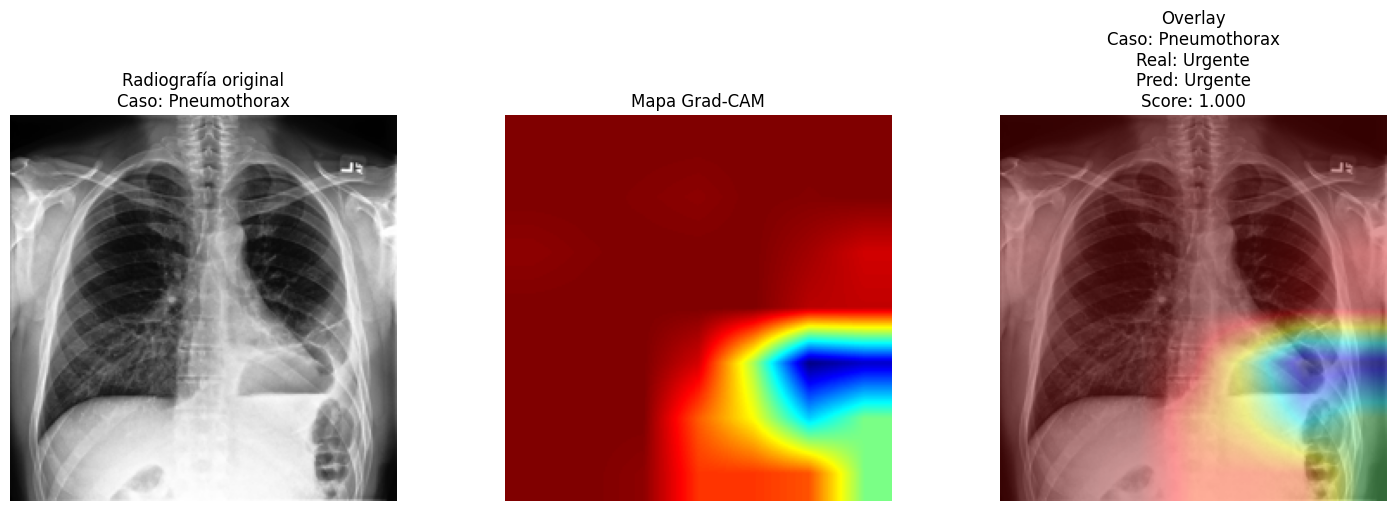

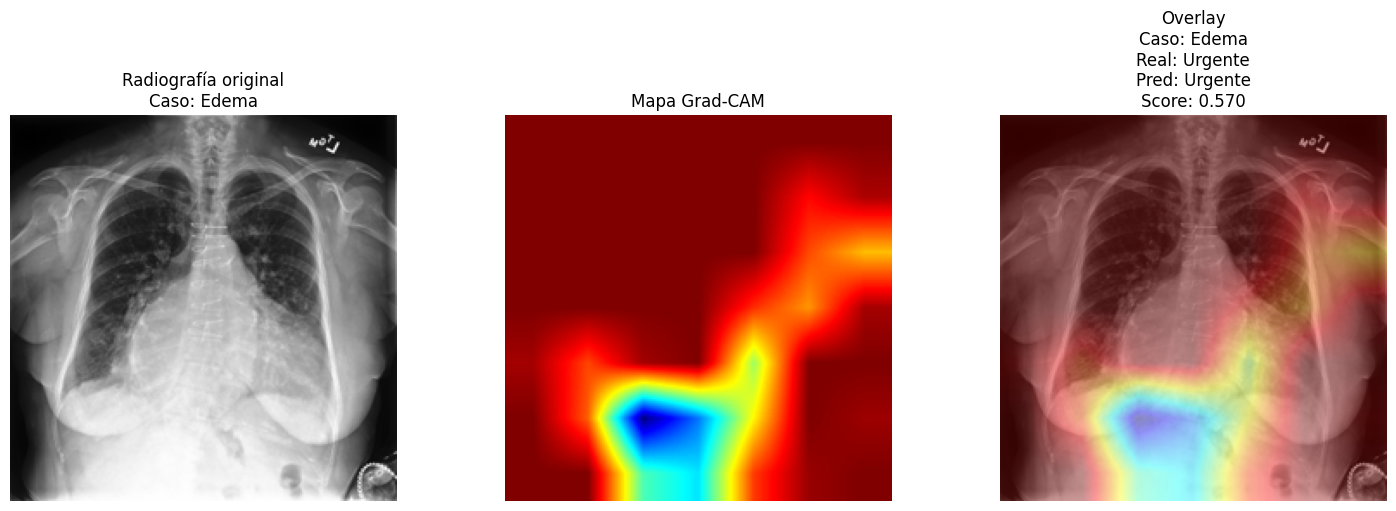

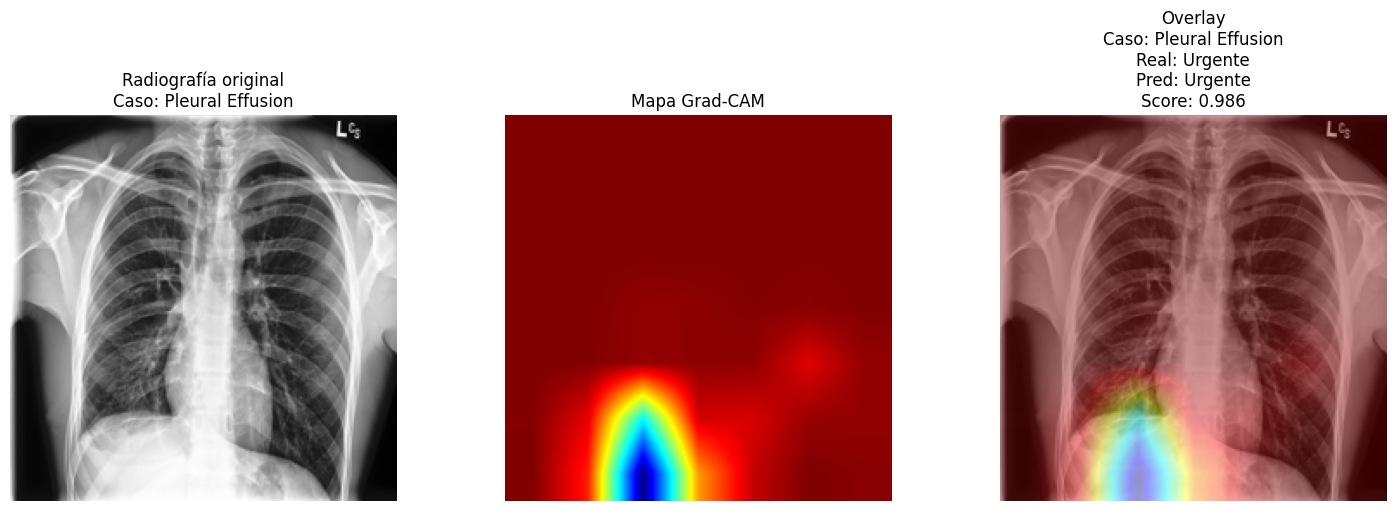

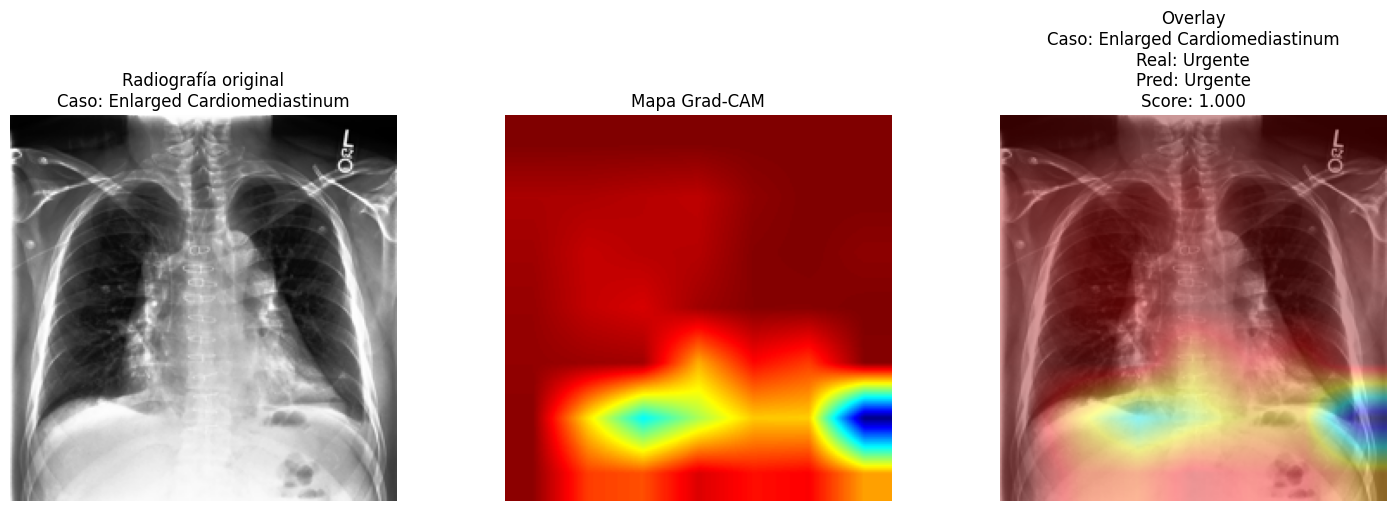

In [ ]:


# GENERAR FIGURAS GRAD-CAM POR CLASE/PATOLOGÍA


for idx, row in examples_df.iterrows():

    relative_path = row["Path"].replace(
        "CheXpert-v1.0/train/",
        ""
    )

    img_path = os.path.join(
        valid_images_path,
        relative_path
    )

    original, heatmap, overlay, score = generate_gradcam(img_path)

    prediction = "Urgente" if score >= 0.4 else "No urgente"
    real_label = "Urgente" if row["urgent"] == 1 else "No urgente"

    case_type = row["case_type"]

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].imshow(original)
    ax[0].set_title(f"Radiografía original\nCaso: {case_type}")
    ax[0].axis("off")

    ax[1].imshow(heatmap)
    ax[1].set_title("Mapa Grad-CAM")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title(
        f"Overlay\n"
        f"Caso: {case_type}\n"
        f"Real: {real_label}\n"
        f"Pred: {prediction}\n"
        f"Score: {score:.3f}"
    )
    ax[2].axis("off")

    plt.tight_layout()

    safe_case_name = case_type.replace(" ", "_").replace("/", "_")

    save_path = os.path.join(
        output_dir,
        f"gradcam_{idx+1}_{safe_case_name}.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:

# FIGURAS GENERADAS


os.listdir(output_dir)

['gradcam_case_1.png',
 'gradcam_case_2.png',
 'gradcam_case_3.png',
 'gradcam_case_4.png',
 'gradcam_case_5.png']